# Method Comparison: Orthorectified vs. Whole-Field Orthomosaic for Tar Spot Disease Representation (PPAC-B3, 2024)

This notebook evaluates which VI-extraction method (`orthorectified` vs `whole`-field
orthomosaic), and which soil-handling option (`SOIL` raw vs masked), produces vegetation
index values that better represent the tar spot disease situation.

Sections:
1. Data loading & structuring
2. Method concordance/agreement (orthorectified vs whole)
3. Univariate VI-severity relationship strength (mixed models)
4. Multivariate predictive comparison (RF / PLSR / Ridge, GroupKFold CV)
5. Temporal / disease-progression analysis
6. Feature importance comparison

## Section 0 — Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, wilcoxon, permutation_test
import statsmodels.formula.api as smf
from statsmodels.graphics.agreement import mean_diff_plot
import pingouin as pg
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_excel("../combined_vi_stats_with_disease_PPAC-B3.xlsx")
df["DATE"] = pd.to_datetime(df["DATE"], format="%m%d%Y").dt.strftime("%m/%d/%Y")

# 08/03/2024 has no SEVERITY at all: the source disease evaluation file is missing the
# "tar7" (Time=7, August 3) column entirely, so there is no ground-truth rating for that
# flight date. Drop these rows for all severity-based analyses below.
df_sev = df.dropna(subset=["SEVERITY"]).reset_index(drop=True)
print("Full data:", df.shape, "| Severity-complete data:", df_sev.shape)
assert df_sev.shape[0] == 3780

vi_mean_cols = [c for c in df.columns if c.endswith("_MEAN")]
vi_all_cols = [c for c in df.columns if c.endswith(("_MEAN", "_STD", "_MIN", "_MAX"))]
methods = ["orthorectified", "whole"]
soils = ["YES", "NO"]

print(f"{len(vi_mean_cols)} mean VI columns:", vi_mean_cols)

Full data: (4320, 56) | Severity-complete data: (3780, 56)
12 mean VI columns: ['NDVI_MEAN', 'NDRE_MEAN', 'EXG_MEAN', 'PSRI_MEAN', 'RDVI_MEAN', 'MCARI2_MEAN', 'RED_MEAN', 'GREEN_MEAN', 'BLUE_MEAN', 'REDEDGE_MEAN', 'NIR_MEAN', 'OSAVI_MEAN']


## Section 1 — Data Structuring for METHOD x SOIL Comparison

In [3]:
# Wide table: one row per (DATE, POINT, SOIL), with paired orthorectified/whole VI values
wide = df_sev.pivot_table(index=["DATE", "POINT", "SOIL"], columns="METHOD", values=vi_mean_cols)
wide.columns = [f"{vi}_{method}" for vi, method in wide.columns]
wide = wide.reset_index()
print(wide.shape)
wide.head()

(1890, 27)


,DATE,POINT,SOIL,BLUE_MEAN_orthorectified,BLUE_MEAN_whole,EXG_MEAN_orthorectified,EXG_MEAN_whole,GREEN_MEAN_orthorectified,GREEN_MEAN_whole,MCARI2_MEAN_orthorectified,...,OSAVI_MEAN_orthorectified,OSAVI_MEAN_whole,PSRI_MEAN_orthorectified,PSRI_MEAN_whole,RDVI_MEAN_orthorectified,RDVI_MEAN_whole,REDEDGE_MEAN_orthorectified,REDEDGE_MEAN_whole,RED_MEAN_orthorectified,RED_MEAN_whole
0,06/17/2024,1,NO,0.047098,0.048181,0.034338,0.031471,0.077125,0.077629,0.163419,...,0.364830,0.351677,-0.011268,-0.001056,0.263981,0.254272,0.124490,0.125336,0.072813,0.075606
1,06/17/2024,1,YES,0.055018,0.056589,0.011946,0.010627,0.079536,0.081342,0.086265,...,0.236202,0.236188,0.080872,0.085118,0.169754,0.170021,0.122292,0.125185,0.092109,0.095468
2,06/17/2024,2,NO,0.047235,0.048245,0.034780,0.033796,0.078511,0.079796,0.165538,...,0.368304,0.361328,-0.006740,-0.000867,0.267438,0.262710,0.128007,0.129992,0.075006,0.077550
3,06/17/2024,2,YES,0.054894,0.056395,0.014002,0.013308,0.081526,0.083729,0.095478,...,0.253362,0.251610,0.077333,0.081508,0.183111,0.182335,0.127784,0.130849,0.094157,0.097756
4,06/17/2024,3,NO,0.046544,0.046923,0.034638,0.033380,0.077190,0.077395,0.169051,...,0.375748,0.368642,-0.008079,-0.004143,0.272884,0.267325,0.126490,0.126702,0.073198,0.074486


In [4]:
# Long data per (METHOD, SOIL) combo, used for Sections 3-6
combo_data = {}
for method in methods:
    for soil in soils:
        sub = df_sev[(df_sev["METHOD"] == method) & (df_sev["SOIL"] == soil)]
        combo_data[(method, soil)] = sub[["POINT", "DATE"] + vi_mean_cols + ["SEVERITY"]].reset_index(drop=True)
        print(method, soil, combo_data[(method, soil)].shape)

orthorectified YES (945, 15)
orthorectified NO (945, 15)
whole YES (945, 15)
whole NO (945, 15)


**Leakage note**: each `POINT` (1-135) appears 7 times within every (METHOD, SOIL) combo
(once per remaining flight date). All cross-validation and grouping below uses
`groups=POINT`, so a plot's repeated-date observations never span both the train and
test folds.

## Section 2 — Method Concordance/Agreement (orthorectified vs whole)

In [5]:
def lin_ccc(x, y):
    """Lin's concordance correlation coefficient."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mx, my = x.mean(), y.mean()
    vx, vy = x.var(), y.var()
    sxy = np.mean((x - mx) * (y - my))
    return 2 * sxy / (vx + vy + (mx - my) ** 2)


concordance_rows = []
for soil in soils:
    sub_wide = wide[wide["SOIL"] == soil]
    for vi in vi_mean_cols:
        col_o, col_w = f"{vi}_orthorectified", f"{vi}_whole"
        x = sub_wide[col_o].to_numpy()
        y = sub_wide[col_w].to_numpy()
        mask = ~(np.isnan(x) | np.isnan(y))
        x, y = x[mask], y[mask]

        ccc = lin_ccc(x, y)

        long_df = pd.DataFrame({
            "subject": np.tile(np.arange(len(x)), 2),
            "rater": ["orthorectified"] * len(x) + ["whole"] * len(x),
            "value": np.concatenate([x, y]),
        })
        icc = pg.intraclass_corr(data=long_df, targets="subject", raters="rater", ratings="value")
        icc2 = icc.loc[icc["Type"] == "ICC(A,1)", "ICC"].values[0]  # ICC2: two-way random, absolute agreement
        icc3 = icc.loc[icc["Type"] == "ICC(C,1)", "ICC"].values[0]  # ICC3: two-way mixed, consistency

        wstat, wp = wilcoxon(x, y)
        rho, _ = spearmanr(x, y)

        diff = y - x
        mean_bias = diff.mean()
        loa_width = 2 * 1.96 * diff.std()

        concordance_rows.append({
            "VI": vi, "SOIL": soil, "CCC": ccc, "ICC2": icc2, "ICC3": icc3,
            "Wilcoxon_p": wp, "Spearman_r": rho, "Mean_bias": mean_bias, "LoA_width": loa_width,
        })

concordance_df = pd.DataFrame(concordance_rows).sort_values(["SOIL", "CCC"]).reset_index(drop=True)
concordance_df

,VI,SOIL,CCC,ICC2,ICC3,Wilcoxon_p,Spearman_r,Mean_bias,LoA_width
0,GREEN_MEAN,NO,0.786353,0.786530,0.911635,1.946619e-148,0.918548,-0.002295,0.006699
1,REDEDGE_MEAN,NO,0.811225,0.811387,0.844173,2.560759e-76,0.878705,-0.002558,0.019643
2,EXG_MEAN,NO,0.967185,0.967219,0.984474,8.917151e-149,0.848848,-0.002636,0.009629
3,NIR_MEAN,NO,0.976942,0.976966,0.982517,1.243964e-128,0.975369,-0.012797,0.087805
4,BLUE_MEAN,NO,0.983142,0.983159,0.994342,3.359374e-140,0.948235,-0.000912,0.002519
5,PSRI_MEAN,NO,0.988892,0.988904,0.990230,1.475553e-32,0.945412,0.001050,0.011058
6,RED_MEAN,NO,0.992535,0.992543,0.995566,1.264510e-110,0.970414,-0.001042,0.004921
7,MCARI2_MEAN,NO,0.992538,0.992546,0.994916,1.633943e-131,0.982339,-0.007368,0.042077
8,RDVI_MEAN,NO,0.993341,0.993348,0.994940,1.771139e-123,0.984269,-0.007858,0.054624
9,OSAVI_MEAN,NO,0.997974,0.997976,0.998441,5.222190e-98,0.988473,-0.004428,0.031667


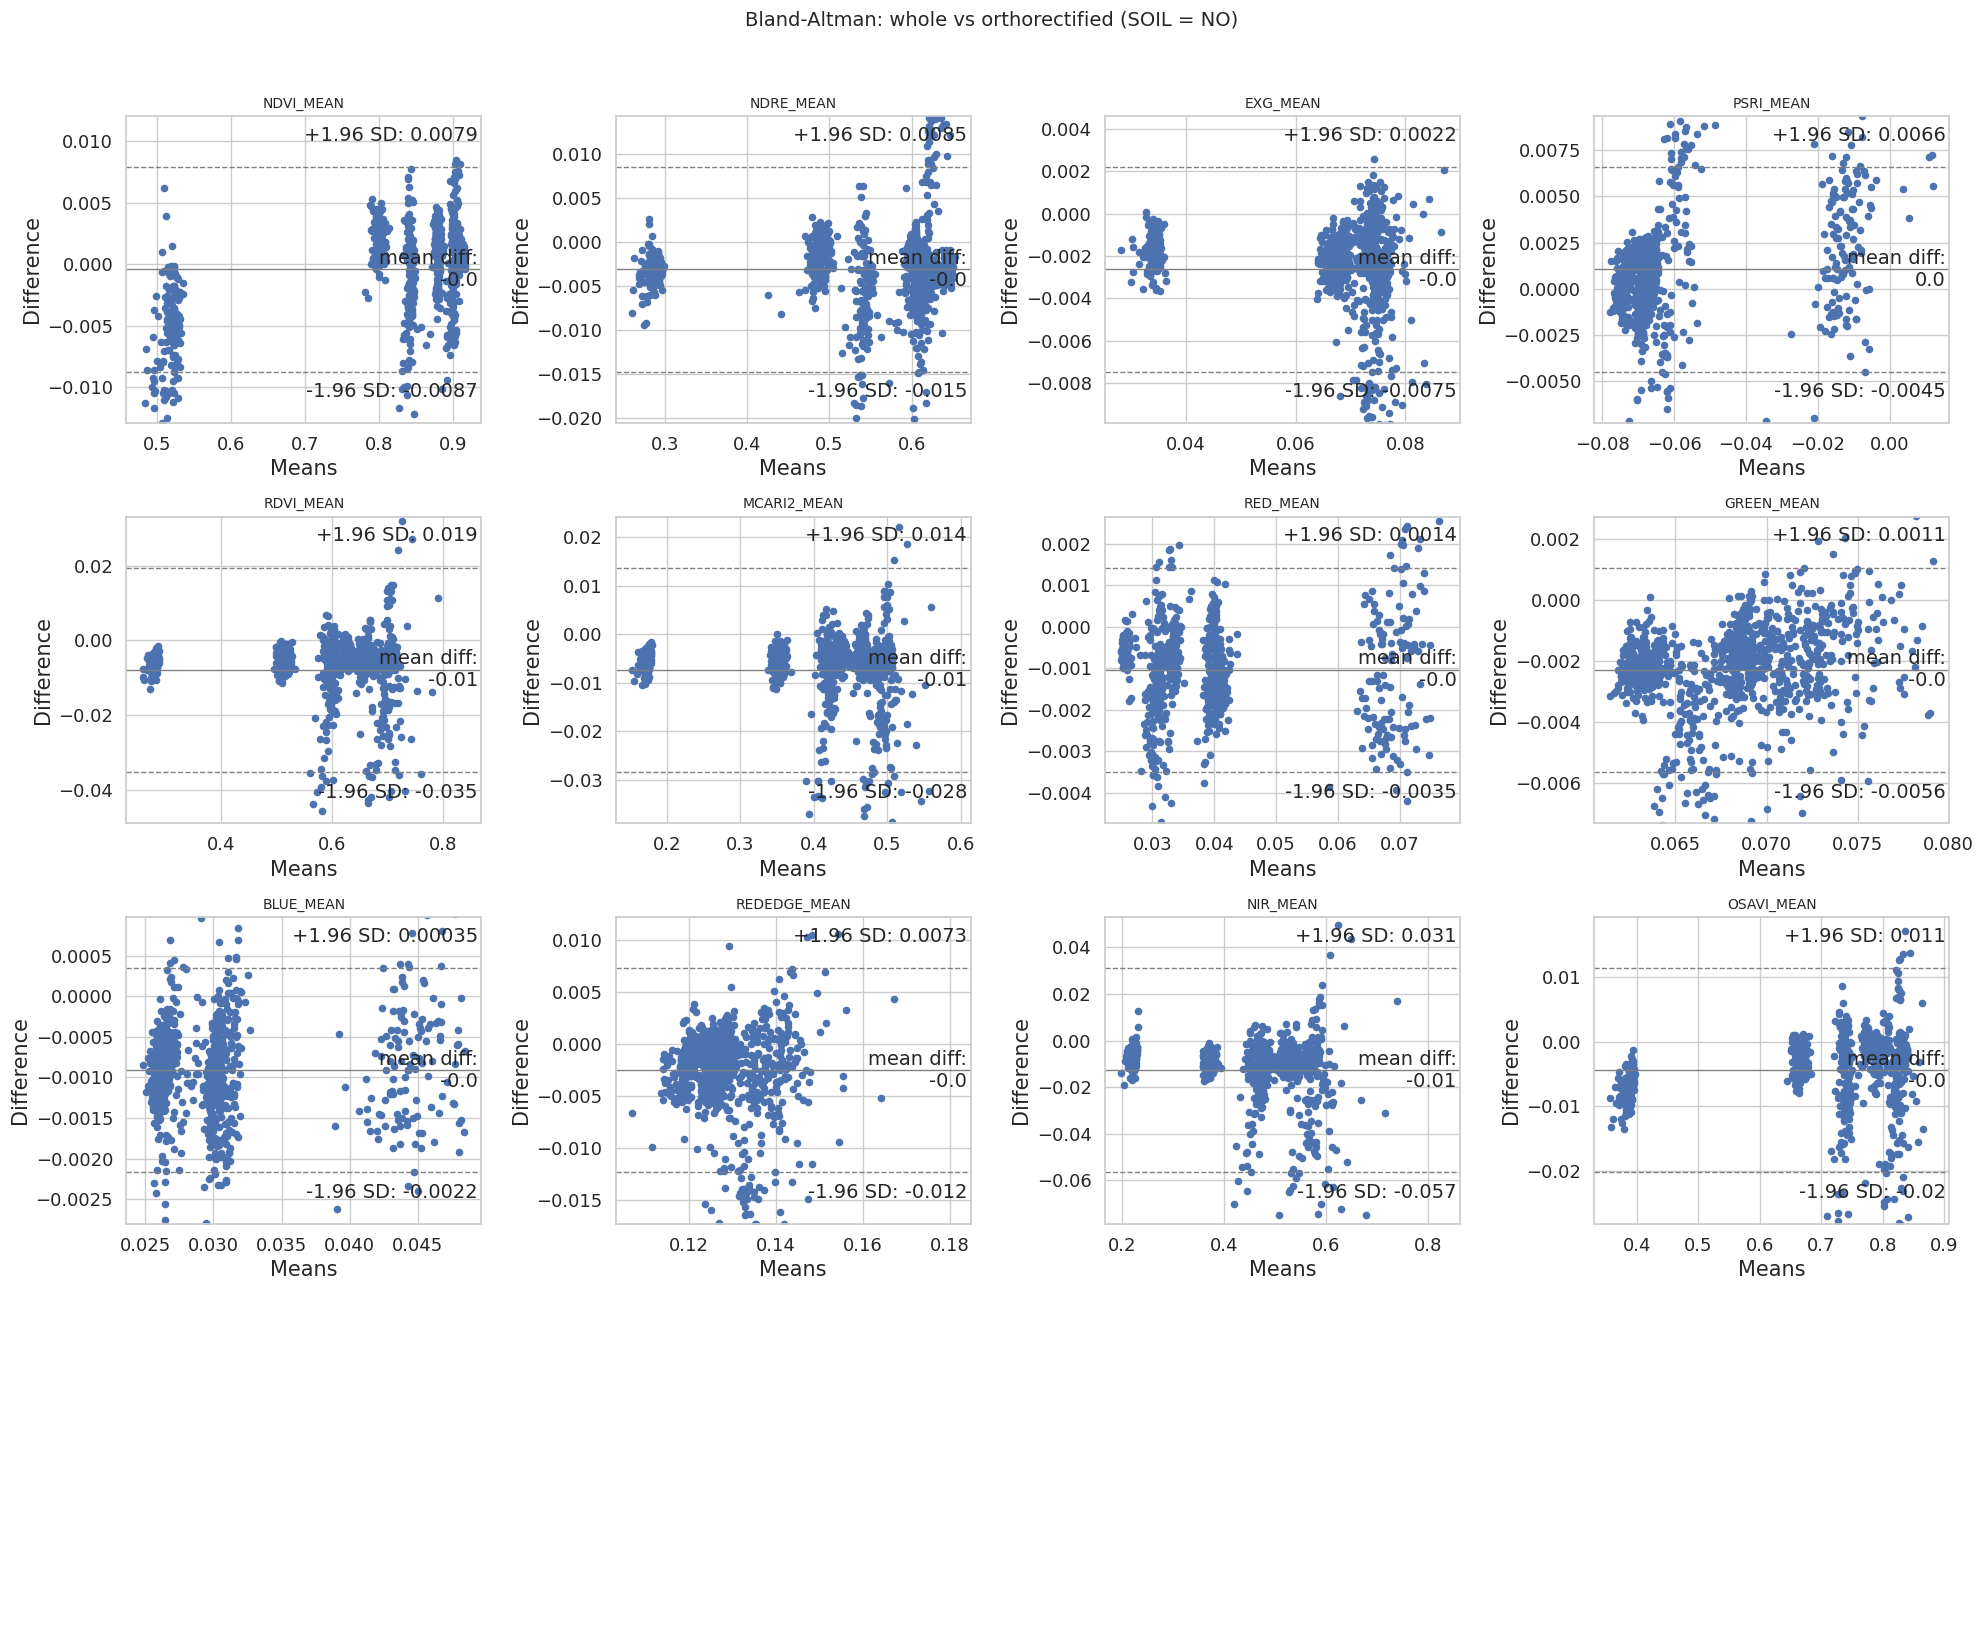

In [6]:
# Bland-Altman plots (whole - orthorectified) for SOIL=NO, all 13 mean VIs
sub_wide = wide[wide["SOIL"] == "NO"]
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, vi in zip(axes.flat, vi_mean_cols):
    x = sub_wide[f"{vi}_orthorectified"].to_numpy()
    y = sub_wide[f"{vi}_whole"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y))
    mean_diff_plot(y[mask], x[mask], ax=ax)
    ax.set_title(vi, fontsize=10)
for ax in axes.flat[len(vi_mean_cols):]:
    ax.axis("off")
fig.suptitle("Bland-Altman: whole vs orthorectified (SOIL = NO)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Section 3 — Univariate VI-Severity Relationship Strength

**Note**: `MixedLM` may print `ConvergenceWarning`s for some VIs (the random-intercept
variance estimate sits near the boundary of the parameter space). This is a common,
largely benign occurrence with unbalanced/near-zero variance components and does not
materially affect the fixed-effect (slope/interaction) estimates used below.

In [7]:
mixed_rows = []
for soil in soils:
    for vi in vi_mean_cols:
        sub = df_sev.loc[df_sev["SOIL"] == soil, ["POINT", "SEVERITY", "METHOD", vi]].dropna()
        sub = sub.rename(columns={vi: "VI"})
        # z-score the VI predictor: puts all VIs (very different raw scales, e.g. EXG ~0.01-0.09
        # vs PSRI ~ -0.2-0.1) on a comparable footing and avoids MixedLM convergence failures
        # caused by scale mismatch between the predictor and SEVERITY (0-6).
        sub["VI"] = (sub["VI"] - sub["VI"].mean()) / sub["VI"].std()

        model = smf.mixedlm("SEVERITY ~ VI * C(METHOD)", data=sub, groups=sub["POINT"], re_formula="~1")
        fit = model.fit()

        params, pvalues = fit.params, fit.pvalues
        interaction_terms = [p for p in params.index if p.startswith("VI:")]
        interaction_term = interaction_terms[0]

        slope_ortho = params["VI"]
        slope_whole = params["VI"] + params[interaction_term]

        mixed_rows.append({
            "VI": vi, "SOIL": soil,
            "interaction_p": pvalues[interaction_term],
            "slope_per_SD_orthorectified": slope_ortho,
            "slope_per_SD_whole": slope_whole,
            "loglik": fit.llf,
        })

mixed_df = pd.DataFrame(mixed_rows).sort_values(["SOIL", "interaction_p"]).reset_index(drop=True)
mixed_df

/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/tingyan/miniconda3/envs/micasense/lib/python3.12/

,VI,SOIL,interaction_p,slope_per_SD_orthorectified,slope_per_SD_whole,loglik
0,EXG_MEAN,NO,0.738958,0.014008,0.035456,-3315.782849
1,GREEN_MEAN,NO,0.743504,0.164442,0.142660,-3305.453699
2,RED_MEAN,NO,0.796292,0.098926,0.082412,-3312.089989
3,NDVI_MEAN,NO,0.838951,-0.065523,-0.052514,-3314.417439
4,OSAVI_MEAN,NO,0.882451,-0.180010,-0.170612,-3301.011820
5,PSRI_MEAN,NO,0.884036,-0.450909,-0.442045,-3213.721161
6,REDEDGE_MEAN,NO,0.892365,0.036358,0.027595,-3315.598214
7,NDRE_MEAN,NO,0.897138,-0.249128,-0.240975,-3286.346168
8,RDVI_MEAN,NO,0.898936,-0.271390,-0.263402,-3280.590472
9,MCARI2_MEAN,NO,0.930993,-0.268816,-0.263368,-3280.960871


In [18]:
fit.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
================================================================
Model:                MixedLM   Dependent Variable:   SEVERITY  
No. Observations:     1890      Method:               REML      
No. Groups:           135       Scale:                1.9070    
Min. group size:      14        Log-Likelihood:       -3301.0118
Max. group size:      14        Converged:            No        
Mean group size:      14.0                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.649    0.045 14.311 0.000  0.560  0.738
C(METHOD)[T.whole]    -0.005    0.064 -0.084 0.933 -0.130  0.119
VI                    -0.180    0.045 -3.989 0.000 -0.268 -0.092
VI:C(METHOD)[T.whole]  0.009    0.064  0.148 0.882 -0.115  0.134
Group Var              0.005                                    
================================================================

"""

In [8]:
# Per-date Spearman correlation (VI vs SEVERITY across 135 points), Fisher-z averaged across dates
spearman_rows = []
for (method, soil), sub in combo_data.items():
    for vi in vi_mean_cols:
        rhos = []
        for _, g in sub.groupby("DATE"):
            r, _ = spearmanr(g[vi], g["SEVERITY"])
            rhos.append(r)
        z = np.arctanh(np.clip(rhos, -0.999, 0.999))
        mean_rho = np.tanh(np.nanmean(z))
        spearman_rows.append({"METHOD": method, "SOIL": soil, "VI": vi, "mean_spearman": mean_rho})

spearman_df = pd.DataFrame(spearman_rows)

# Merge mean Spearman rho's into the mixed-model comparison table
comparison_df = mixed_df.copy()
for method in methods:
    pivot = spearman_df[spearman_df["METHOD"] == method].set_index(["VI", "SOIL"])["mean_spearman"]
    comparison_df[f"mean_spearman_{method}"] = comparison_df.set_index(["VI", "SOIL"]).index.map(pivot)

comparison_df

/tmp/ipykernel_98323/2227453776.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])


,VI,SOIL,interaction_p,slope_per_SD_orthorectified,slope_per_SD_whole,loglik,mean_spearman_orthorectified,mean_spearman_whole
0,EXG_MEAN,NO,0.738958,0.014008,0.035456,-3315.782849,0.010008,0.023878
1,GREEN_MEAN,NO,0.743504,0.164442,0.142660,-3305.453699,-0.015321,-0.005430
2,RED_MEAN,NO,0.796292,0.098926,0.082412,-3312.089989,-0.074598,-0.064754
3,NDVI_MEAN,NO,0.838951,-0.065523,-0.052514,-3314.417439,-0.054530,0.002047
4,OSAVI_MEAN,NO,0.882451,-0.180010,-0.170612,-3301.011820,-0.124427,-0.060988
5,PSRI_MEAN,NO,0.884036,-0.450909,-0.442045,-3213.721161,-0.184678,-0.117914
6,REDEDGE_MEAN,NO,0.892365,0.036358,0.027595,-3315.598214,-0.023100,-0.015015
7,NDRE_MEAN,NO,0.897138,-0.249128,-0.240975,-3286.346168,-0.084624,-0.004528
8,RDVI_MEAN,NO,0.898936,-0.271390,-0.263402,-3280.590472,-0.135478,-0.081501
9,MCARI2_MEAN,NO,0.930993,-0.268816,-0.263368,-3280.960871,-0.121808,-0.065754


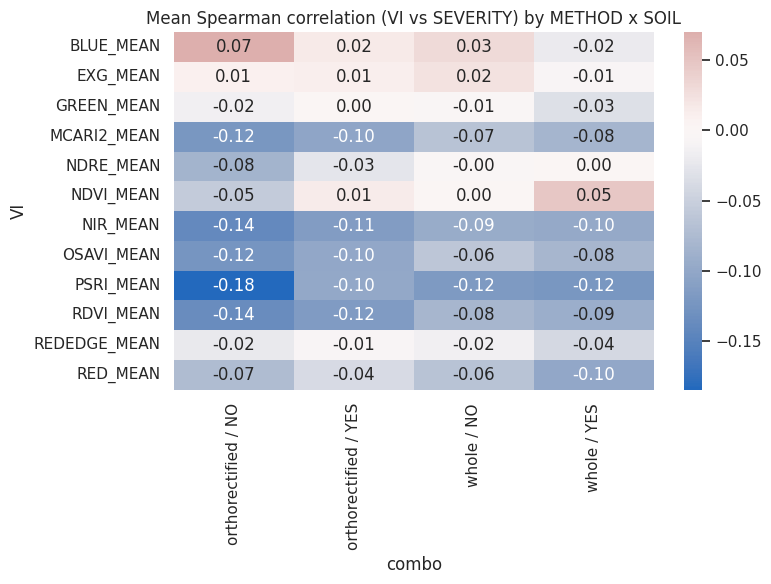

In [9]:
# Heatmap of mean Spearman rho by VI x (METHOD, SOIL)
heat = spearman_df.copy()
heat["combo"] = heat["METHOD"] + " / " + heat["SOIL"]
heat_pivot = heat.pivot(index="VI", columns="combo", values="mean_spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(heat_pivot, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Mean Spearman correlation (VI vs SEVERITY) by METHOD x SOIL")
plt.tight_layout()
plt.show()

## Section 4 — Multivariate Predictive Comparison

**RF vs PLSR vs Ridge tradeoff**: `RandomForestRegressor` matches the teammate's approach
and can capture non-linear/interaction effects, but its importances can be unstable and
biased toward correlated features (the 13 VIs here are highly collinear). `PLSRegression`
projects the predictors onto a small number of latent components that maximize covariance
with the response, handling collinearity by construction and giving more stable, interpretable
loadings/VIP scores. `RidgeCV` is included as a simple linear baseline.

In [10]:
cv = GroupKFold(n_splits=5)

def make_models():
    return {
        "RF": RandomForestRegressor(n_estimators=500, random_state=42),
        "PLSR": Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=4))]),
        "Ridge": Pipeline([("scaler", StandardScaler()), ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 13)))]),
    }

cv_rows = []
fitted_models = {}  # (method, soil, model_name) -> list of fitted models, one per fold

for (method, soil), sub in combo_data.items():
    X = sub[vi_mean_cols].to_numpy()
    y = sub["SEVERITY"].to_numpy()
    groups = sub["POINT"].to_numpy()
    models = make_models()

    for model_name, model in models.items():
        fitted_models[(method, soil, model_name)] = []
        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
            m = clone(model)
            m.fit(X[train_idx], y[train_idx])
            pred = m.predict(X[test_idx]).ravel()

            cv_rows.append({
                "METHOD": method, "SOIL": soil, "MODEL": model_name, "FOLD": fold_idx,
                "R2": r2_score(y[test_idx], pred),
                "RMSE": np.sqrt(mean_squared_error(y[test_idx], pred)),
                "MAE": mean_absolute_error(y[test_idx], pred),
            })
            fitted_models[(method, soil, model_name)].append(m)

cv_df = pd.DataFrame(cv_rows)
cv_df.groupby(["SOIL", "MODEL", "METHOD"])[["R2", "RMSE", "MAE"]].agg(["mean", "std"])

R2                RMSE                 MAE  \
                               mean       std      mean       std      mean   
SOIL MODEL METHOD                                                             
NO   PLSR  orthorectified  0.721616  0.022164  0.733058  0.037579  0.572389   
           whole           0.657313  0.022058  0.813334  0.031807  0.622213   
     RF    orthorectified  0.927825  0.055840  0.352526  0.124530  0.121652   
           whole           0.914843  0.067420  0.383036  0.133896  0.131781   
     Ridge orthorectified  0.883455  0.040153  0.468636  0.070341  0.294605   
           whole           0.852229  0.047642  0.527703  0.073741  0.327771   
YES  PLSR  orthorectified  0.752304  0.027452  0.691606  0.052809  0.513833   
           whole           0.727670  0.025056  0.725355  0.049233  0.535644   
     RF    orthorectified  0.951067  0.019651  0.301214  0.057319  0.106619   
           whole           0.950451  0.020025  0.302683  0.056651  0.107732   
     Ridge orthorectified  0.915348  0.011322  0.403409  0.026130  0.254840   
           whole           0.902754  0.015175  0.431830  0.025013  0.269716   

                                     
                                std  
SOIL MODEL METHOD                    
NO   PLSR  orthorectified  0.022872  
           whole           0.026366  
     RF    orthorectified  0.033882  
           whole           0.039233  
     Ridge orthorectified  0.039137  
           whole           0.041061  
YES  PLSR  orthorectified  0.034662  
           whole           0.034846  
     RF    orthorectified  0.017304  
           whole           0.018694  
     Ridge orthorectified  0.010140  
           whole           0.011492

In [11]:
# Paired comparison: orthorectified vs whole, same SOIL/MODEL/fold
paired_rows = []
for soil in soils:
    for model_name in ["RF", "PLSR", "Ridge"]:
        for metric in ["R2", "RMSE", "MAE"]:
            ortho = (cv_df[(cv_df.METHOD == "orthorectified") & (cv_df.SOIL == soil) & (cv_df.MODEL == model_name)]
                     .sort_values("FOLD")[metric].to_numpy())
            whole = (cv_df[(cv_df.METHOD == "whole") & (cv_df.SOIL == soil) & (cv_df.MODEL == model_name)]
                     .sort_values("FOLD")[metric].to_numpy())

            wstat, wp = wilcoxon(ortho, whole)
            perm = permutation_test((ortho, whole), statistic=lambda a, b: np.mean(a - b),
                                     permutation_type="samples", n_resamples=10000, random_state=42)

            paired_rows.append({
                "SOIL": soil, "MODEL": model_name, "METRIC": metric,
                "mean_orthorectified": ortho.mean(), "mean_whole": whole.mean(),
                "median_diff_(ortho-whole)": np.median(ortho - whole),
                "wilcoxon_p": wp, "permutation_p": perm.pvalue,
            })

paired_df = pd.DataFrame(paired_rows)
paired_df

,SOIL,MODEL,METRIC,mean_orthorectified,mean_whole,median_diff_(ortho-whole),wilcoxon_p,permutation_p
0,YES,RF,R2,0.951067,0.950451,0.001385,1.0000,0.8750
1,YES,RF,RMSE,0.301214,0.302683,-0.006183,1.0000,0.9375
2,YES,RF,MAE,0.106619,0.107732,-0.005998,1.0000,0.8750
3,YES,PLSR,R2,0.752304,0.727670,0.023486,0.0625,0.0625
4,YES,PLSR,RMSE,0.691606,0.725355,-0.032050,0.0625,0.0625
5,YES,PLSR,MAE,0.513833,0.535644,-0.024272,0.0625,0.0625
6,YES,Ridge,R2,0.915348,0.902754,0.012758,0.1250,0.1250
7,YES,Ridge,RMSE,0.403409,0.431830,-0.027869,0.1250,0.1250
8,YES,Ridge,MAE,0.254840,0.269716,-0.015941,0.1250,0.1250
9,NO,RF,R2,0.927825,0.914843,0.015013,0.1250,0.1250


## Section 5 — Temporal / Disease-Progression Analysis

In [12]:
# Stratify by flight-date group (early-season, low/emerging severity vs late-season, high severity)
early_dates = ["06/17/2024", "07/11/2024", "07/23/2024"]
late_dates = ["08/13/2024", "08/19/2024", "09/01/2024", "09/08/2024"]

def date_group(d):
    return "early" if d in early_dates else "late"

df_sev["DATE_GROUP"] = df_sev["DATE"].map(date_group)
print(df_sev.groupby("DATE_GROUP")["SEVERITY"].describe()[["count", "mean", "min", "max"]])

             count      mean       min       max
DATE_GROUP                                      
early       1620.0  0.000228  0.000000  0.005556
late        2160.0  1.130572  0.020833  6.021894


/tmp/ipykernel_98323/4181908703.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])
/tmp/ipykernel_98323/4181908703.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])
/tmp/ipykernel_98323/4181908703.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])
/tmp/ipykernel_98323/4181908703.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g[vi], g["SEVERITY"])


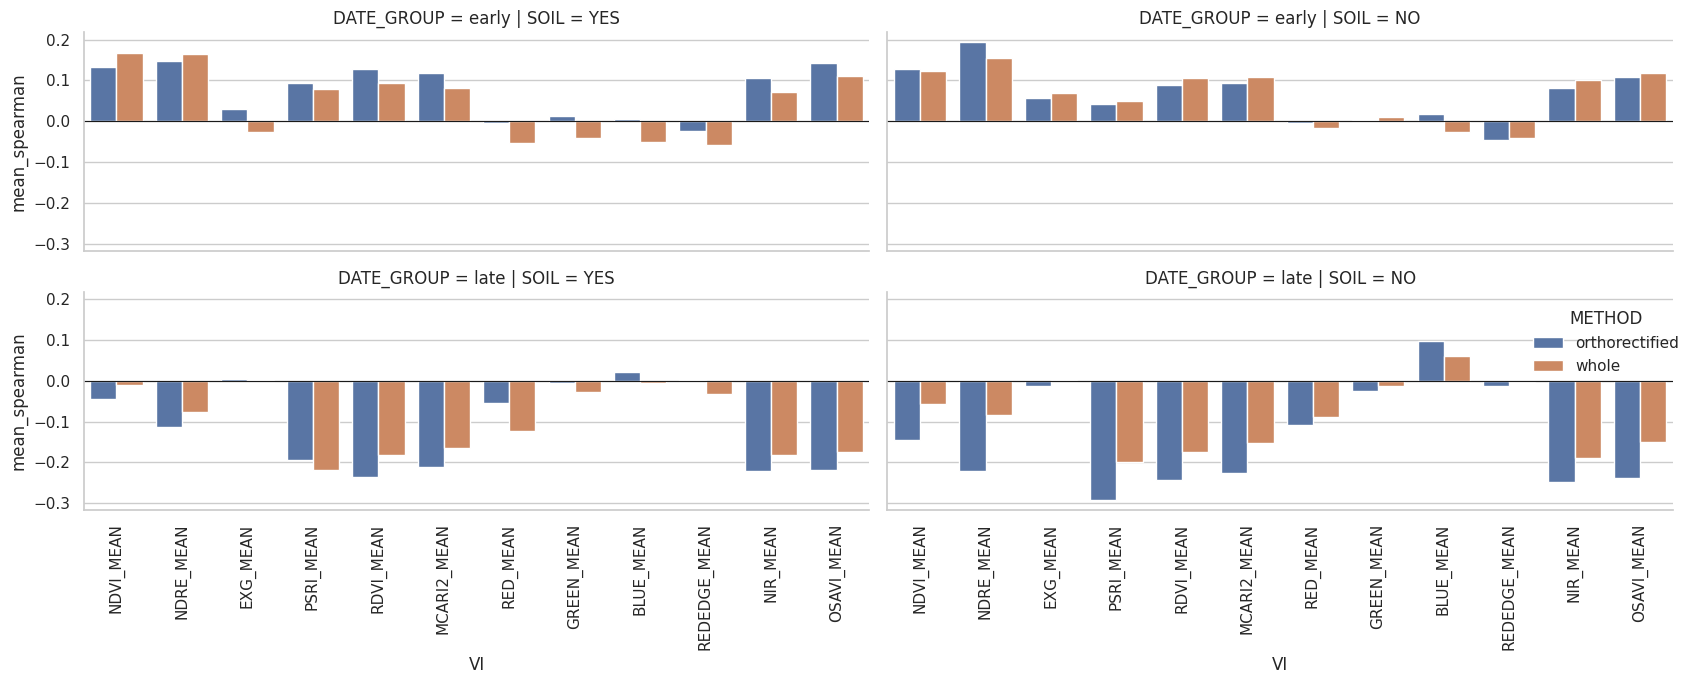

In [13]:
# Spearman correlation strength (VI vs SEVERITY) per date group, METHOD, SOIL
strat_spearman_rows = []
for (method, soil), _ in combo_data.items():
    sub_full = df_sev[(df_sev["METHOD"] == method) & (df_sev["SOIL"] == soil)]
    for group in ["early", "late"]:
        sub = sub_full[sub_full["DATE_GROUP"] == group]
        for vi in vi_mean_cols:
            rhos = []
            for _, g in sub.groupby("DATE"):
                r, _ = spearmanr(g[vi], g["SEVERITY"])
                rhos.append(r)
            z = np.arctanh(np.clip(rhos, -0.999, 0.999))
            mean_rho = np.tanh(np.nanmean(z))
            strat_spearman_rows.append({"METHOD": method, "SOIL": soil, "DATE_GROUP": group,
                                         "VI": vi, "mean_spearman": mean_rho})

strat_spearman_df = pd.DataFrame(strat_spearman_rows)

g = sns.catplot(
    data=strat_spearman_df, x="VI", y="mean_spearman", hue="METHOD",
    col="SOIL", row="DATE_GROUP", kind="bar", height=3.5, aspect=2.2,
)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=90)
    ax.axhline(0, color="k", lw=0.8)
plt.tight_layout()
plt.show()

In [14]:
# Predictive R2 within each date-group, METHOD, SOIL (GroupKFold(3) - fewer dates per group)
strat_cv = GroupKFold(n_splits=3)
strat_cv_rows = []

for (method, soil), _ in combo_data.items():
    sub_full = df_sev[(df_sev["METHOD"] == method) & (df_sev["SOIL"] == soil)]
    for group in ["early", "late"]:
        sub = sub_full[sub_full["DATE_GROUP"] == group]
        X = sub[vi_mean_cols].to_numpy()
        y = sub["SEVERITY"].to_numpy()
        groups_arr = sub["POINT"].to_numpy()

        for model_name, model in make_models().items():
            for fold_idx, (train_idx, test_idx) in enumerate(strat_cv.split(X, y, groups_arr)):
                m = clone(model)
                m.fit(X[train_idx], y[train_idx])
                pred = m.predict(X[test_idx]).ravel()
                strat_cv_rows.append({
                    "METHOD": method, "SOIL": soil, "DATE_GROUP": group, "MODEL": model_name,
                    "FOLD": fold_idx, "R2": r2_score(y[test_idx], pred),
                })

strat_cv_df = pd.DataFrame(strat_cv_rows)
strat_cv_df.groupby(["DATE_GROUP", "SOIL", "MODEL", "METHOD"])["R2"].agg(["mean", "std"])

mean       std
DATE_GROUP SOIL MODEL METHOD                            
early      NO   PLSR  orthorectified  0.025040  0.079728
                      whole           0.013362  0.143157
                RF    orthorectified -0.320578  0.411970
                      whole          -0.039257  0.092310
                Ridge orthorectified  0.022996  0.040864
                      whole           0.015015  0.120292
           YES  PLSR  orthorectified  0.012622  0.037471
                      whole           0.068013  0.062942
                RF    orthorectified -0.218229  0.269131
                      whole          -0.050999  0.071339
                Ridge orthorectified -0.005468  0.086046
                      whole           0.077921  0.043623
late       NO   PLSR  orthorectified  0.897397  0.048229
                      whole           0.860582  0.077393
                RF    orthorectified  0.940691  0.019401
                      whole           0.937283  0.013754
                Ridge orthorectified  0.913934  0.039381
                      whole           0.901197  0.037486
           YES  PLSR  orthorectified  0.928064  0.024874
                      whole           0.898708  0.046461
                RF    orthorectified  0.943780  0.008886
                      whole           0.941642  0.020152
                Ridge orthorectified  0.932368  0.015279
                      whole           0.935723  0.016362

**Note on "early" R2 values**: in the early-season window SEVERITY is essentially zero
for almost every plot (mean 0.0002, max 0.0056) — there is virtually no disease signal to
predict yet. Negative/near-zero R2 in this window is therefore expected (a model can't
beat predicting the near-constant mean) and should be read as "no detectable disease
signal pre-onset" rather than as a model failure. The "late" window, where severity has
real spread (mean 1.13, max 6.02), is where method differences in predictive power are
meaningful.

## Section 6 — Feature Importance Comparison

In [15]:
def vip_scores(pls):
    """Variable Importance in Projection for a fitted PLSRegression."""
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)
    vips = np.zeros(p)
    for i in range(p):
        weight = np.array([(w[i, j] / np.linalg.norm(w[:, j])) ** 2 for j in range(h)])
        vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
    return vips


importance_rows = []
for (method, soil) in combo_data:
    rf_models = fitted_models[(method, soil, "RF")]
    rf_imp = np.mean([m.feature_importances_ for m in rf_models], axis=0)
    rf_imp_std = np.std([m.feature_importances_ for m in rf_models], axis=0)

    pls_models = fitted_models[(method, soil, "PLSR")]
    pls_vip = np.mean([vip_scores(m.named_steps["pls"]) for m in pls_models], axis=0)

    for i, vi in enumerate(vi_mean_cols):
        importance_rows.append({
            "METHOD": method, "SOIL": soil, "VI": vi,
            "RF_importance": rf_imp[i], "RF_importance_std": rf_imp_std[i],
            "PLSR_VIP": pls_vip[i],
        })

importance_df = pd.DataFrame(importance_rows)
importance_df.head()

/tmp/ipykernel_98323/1161219334.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
/tmp/ipykernel_98323/1161219334.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
/tmp/ipykernel_98323/1161219334.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  vips[i] = np.sqrt(p * float(s.T @ weight) / total_s)
/tmp/ipykernel_98323/1161219334.py:12: DeprecationWarni

,METHOD,SOIL,VI,RF_importance,RF_importance_std,PLSR_VIP
0,orthorectified,YES,NDVI_MEAN,0.071093,0.047255,0.488928
1,orthorectified,YES,NDRE_MEAN,0.032552,0.008599,0.740571
2,orthorectified,YES,EXG_MEAN,0.013640,0.013596,1.000877
3,orthorectified,YES,PSRI_MEAN,0.465001,0.024675,1.401937
4,orthorectified,YES,RDVI_MEAN,0.077555,0.017324,0.888529


In [16]:
# Rank agreement between orthorectified and whole (within each SOIL)
rank_rows = []
for soil in soils:
    for score_col in ["RF_importance", "PLSR_VIP"]:
        pivot = importance_df[importance_df["SOIL"] == soil].pivot(index="VI", columns="METHOD", values=score_col)
        rho, p = spearmanr(pivot["orthorectified"], pivot["whole"])
        rank_rows.append({"SOIL": soil, "SCORE": score_col, "rank_spearman_rho": rho, "p_value": p})

pd.DataFrame(rank_rows)

,SOIL,SCORE,rank_spearman_rho,p_value
0,YES,RF_importance,0.867133,2.598118e-04
1,YES,PLSR_VIP,0.972028,1.286812e-07
2,NO,RF_importance,0.405594,1.908359e-01
3,NO,PLSR_VIP,0.944056,3.927261e-06


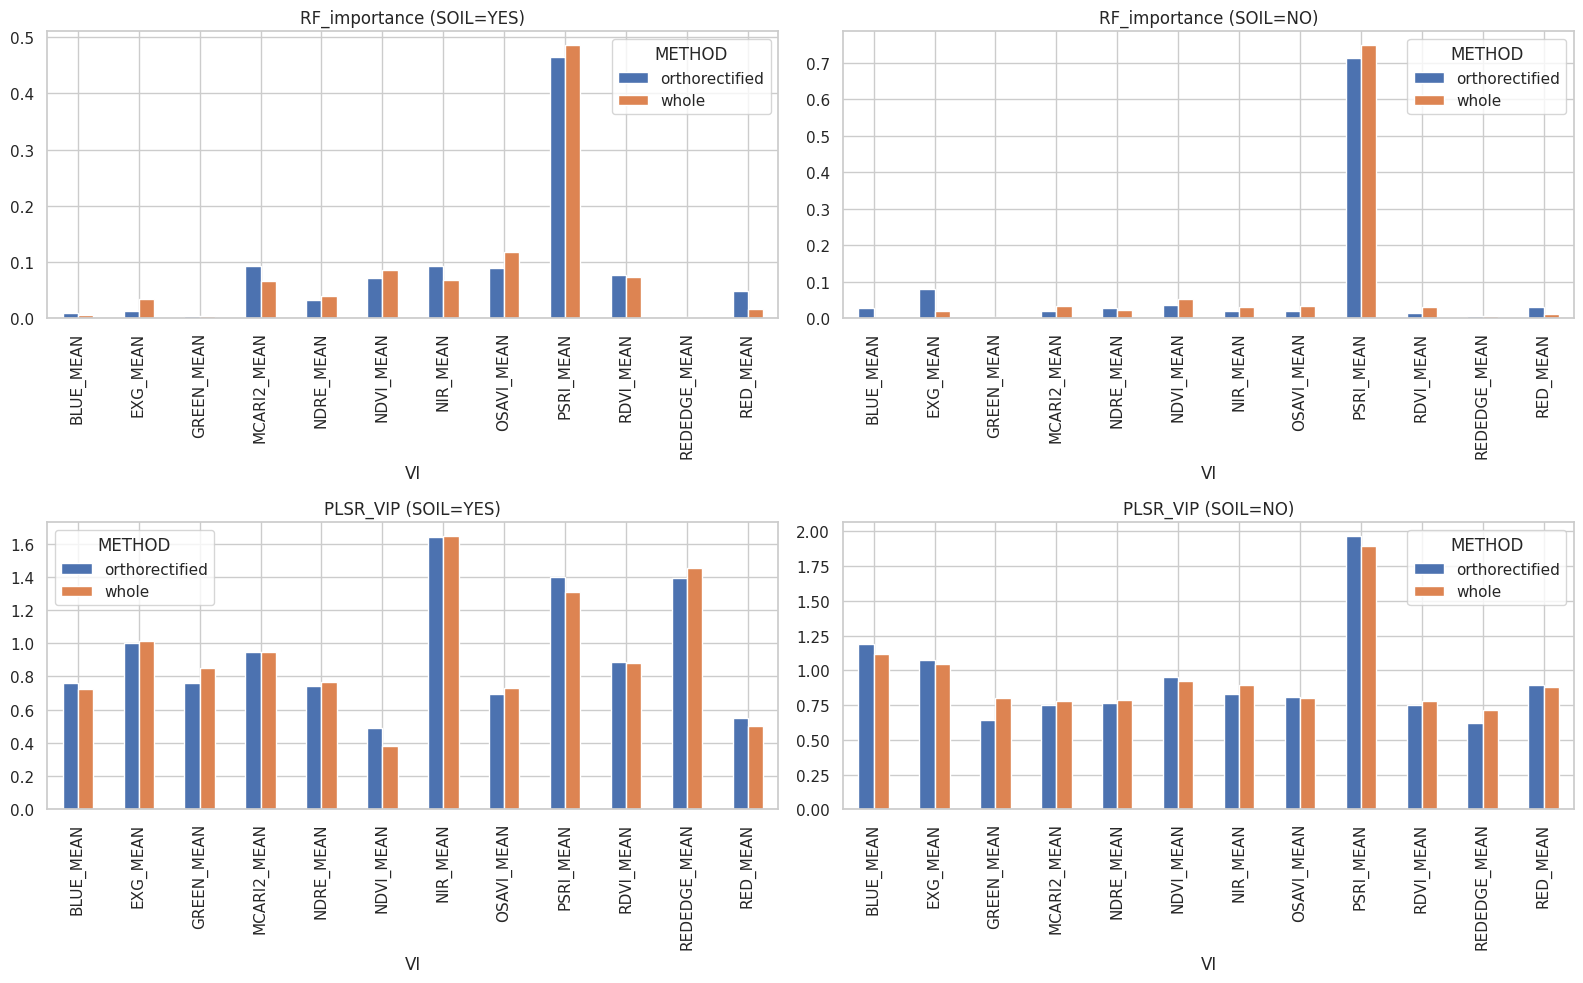

In [17]:
# Side-by-side bar charts: RF importance and PLSR VIP, orthorectified vs whole, per SOIL
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for row, score_col in enumerate(["RF_importance", "PLSR_VIP"]):
    for col, soil in enumerate(soils):
        ax = axes[row, col]
        sub = importance_df[importance_df["SOIL"] == soil]
        plot_df = sub.pivot(index="VI", columns="METHOD", values=score_col)
        plot_df.plot(kind="bar", ax=ax)
        ax.set_title(f"{score_col} (SOIL={soil})")
        ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()